In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("C:/Users/josem/Downloads/merged_dataset.csv")



In [41]:
military_2022 = df[(df['aid_type_general'] == 'Military') & (df['Year'] == 2022)]
# Convert to numeric, coercing errors to NaN
military_2022['source_reported_value_numeric'] = pd.to_numeric(
    military_2022['source_reported_value'], 
    errors='coerce'
)
country_military_aid_2022 = military_2022.groupby('Country Name')['source_reported_value_numeric'].sum().reset_index()

# Group by country and sum the military aid
country_military_aid_2022 = military_2022.groupby('Country Name')['source_reported_value_numeric'].sum().reset_index()

# Remove countries with all NaN values
country_military_aid_2022 = country_military_aid_2022.dropna(subset=['source_reported_value_numeric'])

country_military_aid_2022 = country_military_aid_2022.rename(
    columns={'source_reported_value_numeric': 'total_military_aid_2022'}
)

# Sort by military aid value
country_military_aid_2022 = country_military_aid_2022.sort_values('total_military_aid_2022', ascending=False)

C:\Users\josem\AppData\Local\Temp\ipykernel_9824\684898739.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  military_2022['source_reported_value_numeric'] = pd.to_numeric(


In [42]:
country_military_aid_2022.head(15)

,Country Name,total_military_aid_2022
31,United States,2.500826e+11
7,Denmark,1.118000e+10
28,Sweden,7.601700e+09
30,United Kingdom,7.043001e+09
22,Norway,5.940667e+09
4,Canada,3.079000e+09
6,Czechia,2.477881e+09
20,Netherlands,2.196224e+09
11,Germany,1.360000e+09
19,Luxembourg,1.050000e+09


In [48]:
country_military_aid_2022 = country_military_aid_2022[country_military_aid_2022['Country Name'] != 'United States']
country_military_aid_2022.head(15)

,Country Name,total_military_aid_2022
7,Denmark,1.118000e+10
28,Sweden,7.601700e+09
30,United Kingdom,7.043001e+09
22,Norway,5.940667e+09
4,Canada,3.079000e+09
6,Czechia,2.477881e+09
20,Netherlands,2.196224e+09
11,Germany,1.360000e+09
19,Luxembourg,1.050000e+09
2,Belgium,1.034148e+09


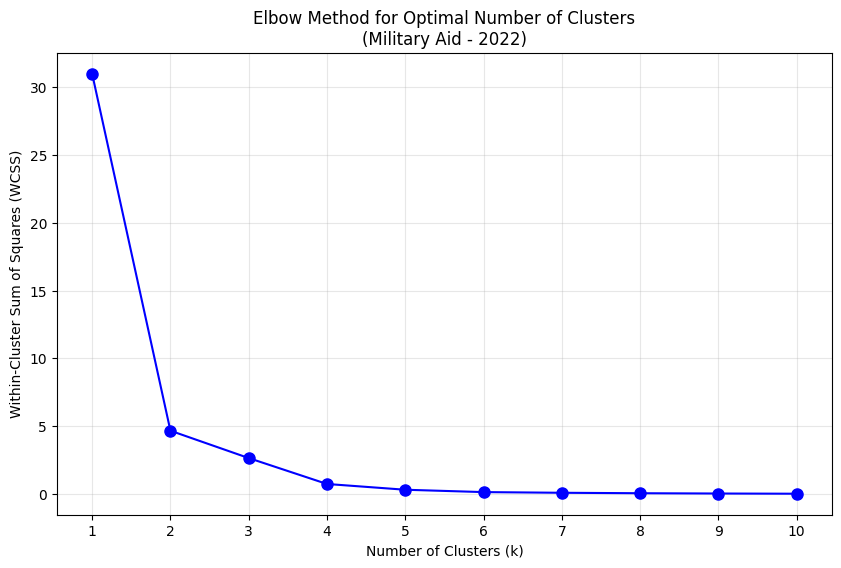

In [49]:
# Prepare data for clustering
X = country_military_aid_2022[['total_military_aid_2022']].values

# Standardize the data (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate WCSS for different numbers of clusters
wcss = []
k_range = range(1, 11)  # Test 1 to 10 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal Number of Clusters\n(Military Aid - 2022)')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.show()

In [51]:
optimal_k = 3

# Perform K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the dataframe
country_military_aid_2022['Cluster'] = clusters
country_military_aid_2022['Cluster_Label'] = country_military_aid_2022['Cluster'].map({0: 'Low', 1: 'Medium', 2: 'High',})

# Get cluster centers in original scale
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

print(f"Cluster Centers (original scale): {cluster_centers_original.flatten()}")

Cluster Centers (original scale): [1.96794414e+08 7.94134192e+09 2.27827614e+09]


C:\Users\josem\AppData\Local\Temp\ipykernel_9824\2169954684.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  country_military_aid_2022['Cluster'] = clusters
C:\Users\josem\AppData\Local\Temp\ipykernel_9824\2169954684.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  country_military_aid_2022['Cluster_Label'] = country_military_aid_2022['Cluster'].map({0: 'Low', 1: 'Medium', 2: 'High',})


In [55]:
# Sort clusters by their center values
sorted_clusters = sorted(
    enumerate(cluster_centers_original.flatten()), 
    key=lambda x: x[1]
)

# Create mapping from cluster number to label
labels = ['Low', 'Medium', 'High']
cluster_label_map = {cluster_num: labels[i] for i, (cluster_num, _) in enumerate(sorted_clusters)}

# Apply the mapping to the dataframe
country_military_aid_2022['Cluster_Label'] = country_military_aid_2022['Cluster'].map(cluster_label_map)

# display results
print("="*60)
print("K-MEANS CLUSTERING RESULTS - Military Aid (2023)")
print("="*60)

for cluster_num, center_value in sorted_clusters:
    cluster_data = country_military_aid_2022[country_military_aid_2022['Cluster'] == cluster_num]
    print(f"\nCLUSTER {cluster_num} ({cluster_label_map[cluster_num]}):")
    print(f"Center: ${center_value:.2f}")
    print(f"Number of countries: {len(cluster_data)}")
    print(f"Countries: {', '.join(cluster_data['Country Name'].tolist())}")
    print(f"Range: ${cluster_data['total_military_aid_2022'].min():.2f} to ${cluster_data['total_military_aid_2022'].max():.2f}")
    print(f"Average: ${cluster_data['total_military_aid_2022'].mean():.2f}")

# Summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Total countries analyzed: {len(country_military_aid_2022)}")
print(f"Global average: ${country_military_aid_2022['total_military_aid_2022'].mean():.2f}")
print(f"Global range: ${country_military_aid_2022['total_military_aid_2022'].min():.2f} to ${country_military_aid_2022['total_military_aid_2022'].max():.2f}")


K-MEANS CLUSTERING RESULTS - Military Aid (2023)

CLUSTER 0 (Low):
Center: $196794413.90
Number of countries: 23
Countries: Luxembourg, Belgium, Australia, France, Finland, Lithuania, Italy, Croatia, Estonia, Spain, New Zealand, Bulgaria, Romania, Iceland, Austria, Ireland, Greece, Latvia, Japan, Poland, Portugal, Slovenia, Turkiye
Range: $0.00 to $1050000000.00
Average: $196794413.90

CLUSTER 2 (Medium):
Center: $2278276139.01
Number of countries: 4
Countries: Canada, Czechia, Netherlands, Germany
Range: $1360000000.00 to $3079000000.00
Average: $2278276139.01

CLUSTER 1 (High):
Center: $7941341916.50
Number of countries: 4
Countries: Denmark, Sweden, United Kingdom, Norway
Range: $5940666666.00 to $11180000000.00
Average: $7941341916.50

SUMMARY STATISTICS
Total countries analyzed: 31
Global average: $1464669152.96
Global range: $0.00 to $11180000000.00


C:\Users\josem\AppData\Local\Temp\ipykernel_9824\148368577.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  country_military_aid_2022['Cluster_Label'] = country_military_aid_2022['Cluster'].map(cluster_label_map)


C:\Users\josem\AppData\Local\Temp\ipykernel_9824\2072433985.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cluster_data, labels=cluster_labels)


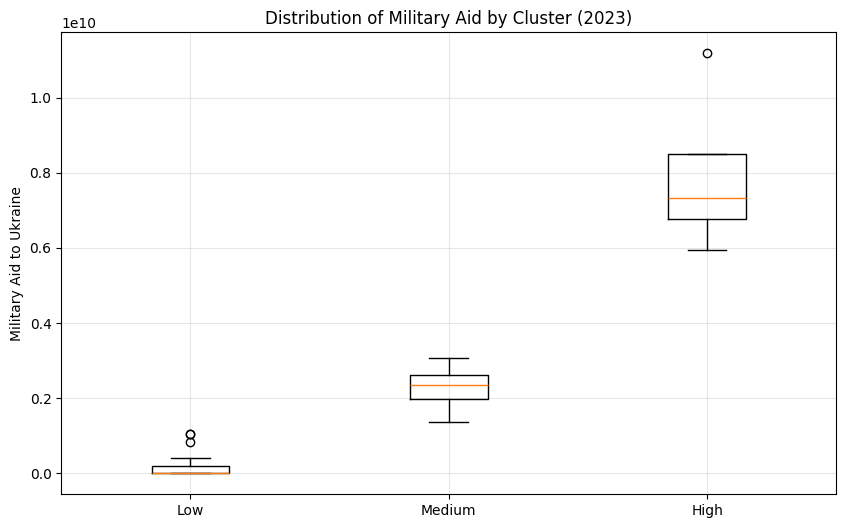

In [56]:
plt.figure(figsize=(10, 6))

# Sort clusters by their actual centers
sorted_clusters = sorted(
    enumerate(cluster_centers_original.flatten()),
    key=lambda x: x[1]
)

# Prepare data and labels in the correct order
cluster_data = []
cluster_labels = []

for cluster_num, _ in sorted_clusters:
    data = country_military_aid_2022[country_military_aid_2022['Cluster'] == cluster_num]['total_military_aid_2022']
    label = country_military_aid_2022.loc[country_military_aid_2022['Cluster'] == cluster_num, 'Cluster_Label'].iloc[0]
    cluster_data.append(data)
    cluster_labels.append(label)

# Create box plot
plt.boxplot(cluster_data, labels=cluster_labels)
plt.ylabel('Military Aid to Ukraine')
plt.title('Distribution of Military Aid by Cluster (2023)')
plt.grid(True, alpha=0.3)
plt.show()
